In [15]:
import sys
from pathlib import Path

root_path = Path.cwd().parent.parent

if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

In [16]:
# Truco para que Jupyter lea siempre la última versión de la carpeta src/
%load_ext autoreload
%autoreload 2

In [17]:
from src.data_loader import loader
from src.model_trainer import optimizar_hiperparametros_modelo
from src.evaluator import evaluar_modelo, calcular_metricas
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import joblib
import src.config as config

In [6]:
X_train, X_test, y_train, y_test = loader(OHE=True)

print("¡Datos cargados con éxito! Tamaño de entrenamiento:", X_train.shape)

¡Datos cargados con éxito! Tamaño de entrenamiento: (95188, 58)


In [9]:
## LOGISTIC REGRESSION

In [10]:
# Definir el modelo
rl_base = LogisticRegression(max_iter=500, random_state=config.RANDOM_STATE)

# Crear el espacio de búsqueda perfecto para Regresión Logística
param_grid_rl = {
    # Probar la regularización L2 (Ridge)
    'penalty': ['l2'],
    'C': [0.01, 0.1, 1, 10],
    # Equilibrar las pérdidas por cancelación
    'class_weight': [None, 'balanced'],
    'solver': ['liblinear'] 
}

In [11]:
print("Buscando la mejor Regresión Logística...")

mejor_rl, hiperparametros_rl = optimizar_hiperparametros_modelo(
    rl_base, 
    param_grid_rl, 
    X_train, 
    y_train
)

print('\n¡Optimización terminada!')
print('Los mejores parámetros encontrados son:\n', hiperparametros_rl)

Buscando la mejor Regresión Logística...


c:\Users\Manuel\Documents\PONTIA\5-ML_DL\Proyecto_MLDL_conClaudi\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(



¡Optimización terminada!
Los mejores parámetros encontrados son:
 {'C': 10, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}



	  Reporte de clasificación (Entrenamiento) - Regresión Logística Optimizada
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.82      0.84     59897
           1       0.72      0.76      0.74     35291

    accuracy                           0.80     95188
   macro avg       0.79      0.79      0.79     95188
weighted avg       0.80      0.80      0.80     95188


	  Reporte de clasificación (Test) - Regresión Logística Optimizada
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.86      0.82      0.84     14974
           1       0.72      0.77      0.74      8823

    accuracy                           0.80     23797
   macro avg       0.79      0.80      0.79     23797
weighted avg       0.81      0.80      0.80     23797



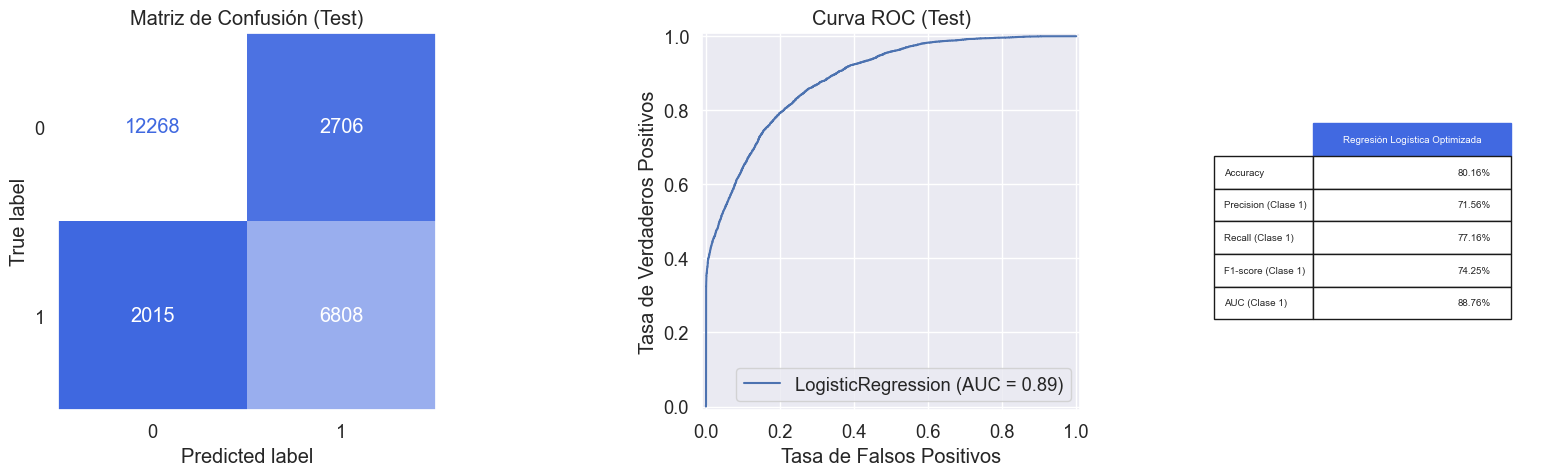

In [12]:
# Evaluación del modelo
evaluar_modelo(mejor_rl, X_train, X_test, y_train, y_test, 'Regresión Logística Optimizada')

In [17]:
rl_results = calcular_metricas(mejor_rl, X_test, y_test, 'Regresión Logística Optimizada')
rl_results

,Regresión Logística Optimizada
Accuracy,80.16%
Precision (Clase 1),71.56%
Recall (Clase 1),77.16%
F1-score (Clase 1),74.25%
AUC (Clase 1),88.76%


In [18]:
joblib.dump(mejor_rl, config.RL_MODEL_PATH)
print(f"¡Modelo guardado en: {config.RL_MODEL_PATH}!")

¡Modelo guardado en: C:\Users\Manuel\Documents\PONTIA\5-ML_DL\Proyecto_MLDL_conClaudi\models\tests\logistic_regression.pkl!


In [3]:
## DECISION TREE

In [19]:
dt_base = DecisionTreeClassifier(random_state=0)

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

mejor_arbol, hiperparametros = optimizar_hiperparametros_modelo(dt_base, param_grid_dt, X_train, y_train)

print('¡Entrenamiento terminado! Los mejores parámetros son:\n', hiperparametros)

¡Entrenamiento terminado! Los mejores parámetros son:
 {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2}



	  Reporte de clasificación (Entrenamiento) - Árbol de Decisión
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.92      0.86      0.89     59897
           1       0.79      0.87      0.83     35291

    accuracy                           0.87     95188
   macro avg       0.85      0.87      0.86     95188
weighted avg       0.87      0.87      0.87     95188


	  Reporte de clasificación (Test) - Árbol de Decisión
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.89      0.83      0.86     14974
           1       0.75      0.83      0.79      8823

    accuracy                           0.83     23797
   macro avg       0.82      0.83      0.83     23797
weighted avg       0.84      0.83      0.84     23797



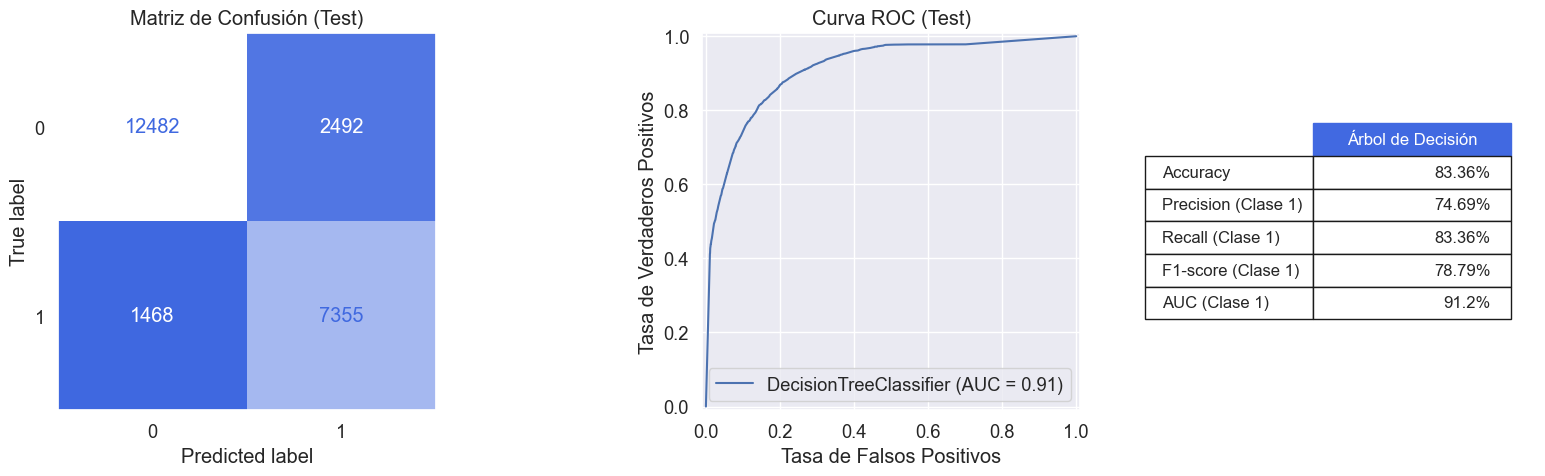

In [20]:
# Métricas de evaluación
evaluar_modelo(mejor_arbol, X_train, X_test, y_train, y_test, 'Árbol de Decisión')

In [21]:
dt_results = calcular_metricas(mejor_arbol, X_test, y_test, 'Árbol de Decisión Optimizado')
dt_results

,Árbol de Decisión Optimizado
Accuracy,83.36%
Precision (Clase 1),74.69%
Recall (Clase 1),83.36%
F1-score (Clase 1),78.79%
AUC (Clase 1),91.2%


In [22]:
# Guardar el modelo en un .pkl
config.MODELS_TEST_DIR.mkdir(parents=True, exist_ok=True)

# 2. Guardamos nuestro árbol ganador usando la ruta de tu config.py
joblib.dump(mejor_arbol, config.DT_MODEL_PATH)

print(f"¡Modelo guardado con éxito en: {config.DT_MODEL_PATH}!")

¡Modelo guardado con éxito en: C:\Users\Manuel\Documents\PONTIA\5-ML_DL\Proyecto_MLDL_conClaudi\models\tests\tree.pkl!


In [7]:
## XGBOOST

# Calcular el peso matemático del desbalanceo para las cancelaciones (Imprescindible para un buen Recall)
total_negativos = (y_train == 0).sum()
total_positivos = (y_train == 1).sum()
peso_cancelaciones = total_negativos / total_positivos

print(f"Peso calculado para XGBoost (scale_pos_weight): {peso_cancelaciones:.2f}")



Peso calculado para XGBoost (scale_pos_weight): 1.70


In [8]:
xgb_base = XGBClassifier(
    random_state=42, 
    scale_pos_weight=peso_cancelaciones,
    eval_metric='logloss'
)

In [9]:
# Diseñar el Grid
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

In [10]:
# Uso la funciónn para buscar los mejores hiperparámetros
mejor_xgb, hiperparametros_xgb = optimizar_hiperparametros_modelo(
    xgb_base, 
    param_grid_xgb, 
    X_train, 
    y_train
)

print("\nEntrenando XGBoost... (Esto puede tardar unos minutos)")
print('\n¡Entrenamiento terminado!')
print('Mejores hiperparámetros:', hiperparametros_xgb)


Entrenando XGBoost... (Esto puede tardar unos minutos)

¡Entrenamiento terminado!
Mejores hiperparámetros: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 200}



	  Reporte de clasificación (Entrenamiento) - XGBoost Optimizado
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.94      0.91      0.92     59897
           1       0.85      0.91      0.88     35291

    accuracy                           0.91     95188
   macro avg       0.90      0.91      0.90     95188
weighted avg       0.91      0.91      0.91     95188


	  Reporte de clasificación (Test) - XGBoost Optimizado
-----------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.87      0.89     14974
           1       0.80      0.86      0.83      8823

    accuracy                           0.87     23797
   macro avg       0.86      0.86      0.86     23797
weighted avg       0.87      0.87      0.87     23797



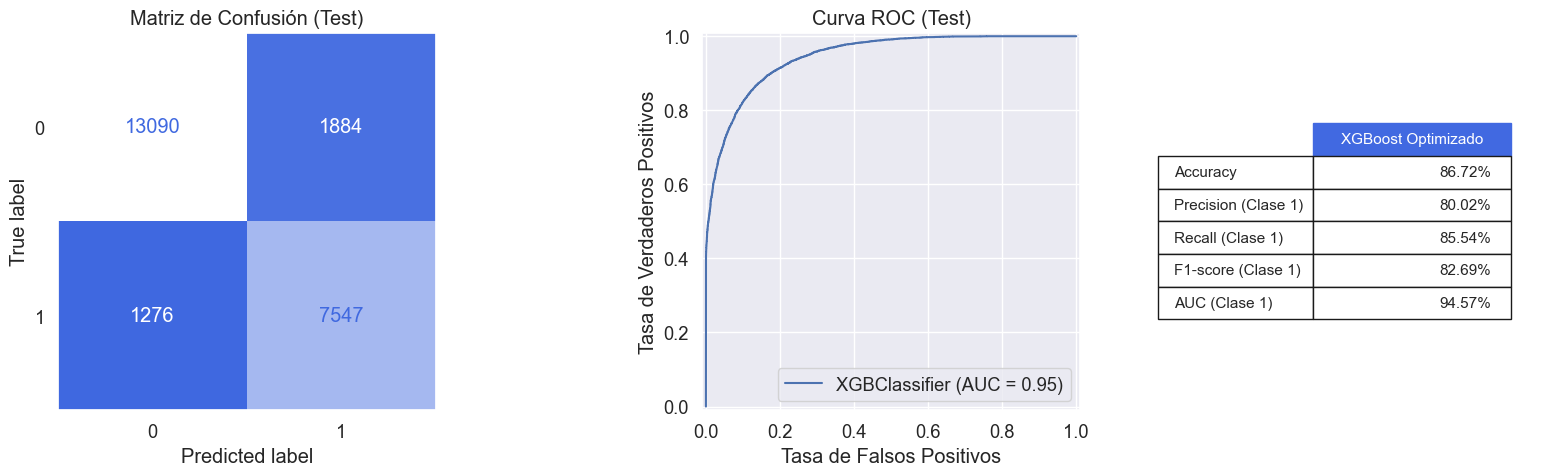

In [11]:
evaluar_modelo(mejor_xgb, X_train, X_test, y_train, y_test, 'XGBoost Optimizado')

In [12]:
xgb_results = calcular_metricas(mejor_xgb, X_test, y_test, 'XGBoost')
xgb_results

,XGBoost
Accuracy,86.72%
Precision (Clase 1),80.02%
Recall (Clase 1),85.54%
F1-score (Clase 1),82.69%
AUC (Clase 1),94.57%


In [13]:
import joblib
joblib.dump(mejor_xgb, config.XGB_MODEL_PATH)

['C:\\Users\\Manuel\\Documents\\PONTIA\\5-ML_DL\\Proyecto_MLDL_conClaudi\\models\\tests\\xgboost.pkl']

In [14]:
# PROBAR EN /PREDICT
import json
import pandas as pd
# Extraer el cliente de prueba
cliente_prueba = X_test.iloc[0:1].to_dict(orient="records")
json_completo = json.dumps({"datos": cliente_prueba})

print(json_completo)

{"datos": [{"hotel_Resort Hotel": 1.0, "meal_FB": 0.0, "meal_HB": 0.0, "meal_SC": 0.0, "meal_Undefined": 0.0, "country_BRA": 0.0, "country_DEU": 0.0, "country_ESP": 0.0, "country_FRA": 0.0, "country_GBR": 0.0, "country_IRL": 0.0, "country_ITA": 0.0, "country_NLD": 0.0, "country_Other": 1.0, "country_PRT": 0.0, "market_segment_Complementary": 0.0, "market_segment_Corporate": 0.0, "market_segment_Direct": 0.0, "market_segment_Groups": 0.0, "market_segment_Offline TA/TO": 1.0, "market_segment_Online TA": 0.0, "market_segment_Undefined": 0.0, "distribution_channel_Direct": 0.0, "distribution_channel_GDS": 0.0, "distribution_channel_TA/TO": 1.0, "distribution_channel_Undefined": 0.0, "reserved_room_type_B": 0.0, "reserved_room_type_C": 0.0, "reserved_room_type_D": 1.0, "reserved_room_type_E": 0.0, "reserved_room_type_F": 0.0, "reserved_room_type_G": 0.0, "reserved_room_type_H": 0.0, "reserved_room_type_L": 0.0, "deposit_type_Non Refund": 0.0, "deposit_type_Refundable": 0.0, "customer_type_G